In [1]:
# ==========================================
# STEP 01: Mount Google Drive
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ==========================================
# STEP 02: Import Libraries
# ==========================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import EfficientNetB0, DenseNet121
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess

In [3]:
# ==========================================
# STEP 03: Dataset Path
# ==========================================
path = "/content/drive/MyDrive/Research/Health_Classification/Data_Set"

classes = ["healthy iris", "unhealthy iris"]

print("Folders found:", os.listdir(path))

Folders found: ['unhealthy iris', 'healthy iris']


In [4]:
# ==========================================
# STEP 04: Sample Images
# ==========================================
for cat in classes:

    class_path = os.path.join(path, cat)

    imgs = os.listdir(class_path)

    print(f"{cat} -> {len(imgs)} images found")

healthy iris -> 584 images found
unhealthy iris -> 594 images found


In [5]:
# ==========================================
# STEP 05: Parameters
# ==========================================
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 25
SPLIT = 0.2

In [6]:
# ==========================================
# STEP 06: Load and Preprocess Dataset
# ==========================================
X = []
Y = []

for i, cat in enumerate(classes):

    images = glob(f"{path}/{cat}/*.jpg") + glob(f"{path}/{cat}/*.JPG")

    for img_path in images:

        img = cv2.imread(img_path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)

        Y.append(i)

X = np.array(X, dtype="float32")
Y = np.array(Y)

print("Total images:", len(X))

Total images: 908


In [7]:
# ==========================================
# STEP 07: One Hot Encoding
# ==========================================
Y_cat = keras.utils.to_categorical(Y, num_classes=len(classes))

In [8]:
# ==========================================
# STEP 08: Train Validation Split
# ==========================================
X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y_cat,
    test_size=SPLIT,
    stratify=Y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 726
Validation samples: 182


In [9]:
# ==========================================
# STEP 09: Medical Safe Data Augmentation
# ==========================================
data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.08),

    layers.RandomZoom(0.08),

    layers.RandomContrast(0.1),

], name="augmentation")

In [10]:
# ======================================================
# STEP 10: Hybrid CNN Model (EfficientNetB0 + DenseNet121)
# ======================================================
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(input_layer)

eff_input = eff_preprocess(x)

dense_input = dense_preprocess(x)

In [11]:
# ==========================================
# EfficientNet Branch
# ==========================================
base_eff = EfficientNetB0(

    include_top=False,
    weights="imagenet",
    input_tensor=eff_input

)

base_eff.trainable = False

eff_feat = layers.GlobalAveragePooling2D()(base_eff.output)

In [12]:
# ==========================================
# DenseNet Branch
# ==========================================
base_dense = DenseNet121(

    include_top=False,
    weights="imagenet",
    input_tensor=dense_input

)

base_dense.trainable = False

dense_feat = layers.GlobalAveragePooling2D()(base_dense.output)

In [13]:
# ==========================================
# STEP 11: Feature Fusion
# ==========================================
combined = layers.Concatenate()([eff_feat, dense_feat])

In [14]:
# ==========================================
# STEP 12: Classification Head
# ==========================================
x = layers.Dense(512, activation="relu")(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(len(classes), activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 256, 256,  │          0 │ augmentation[0][… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 256, 256,  │          0 │ add[0][0]         │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ true_divide_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r

 Total params: 12,402,149 (47.31 MB)

 Trainable params: 1,313,538 (5.01 MB)

 Non-trainable params: 11,088,611 (42.30 MB)

In [15]:
# ==========================================
# STEP 13: Compile Model
# ==========================================
model.compile(

    optimizer=keras.optimizers.Adam(learning_rate=1e-4),

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

In [16]:
# ==========================================
# STEP 14: Training
# ==========================================
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        verbose=1
    )

]

In [17]:

history = model.fit(

    X_train,
    Y_train,

    validation_data=(X_val, Y_val),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 369s 15s/step - accuracy: 0.5678 - loss: 1.0869 - val_accuracy: 0.6868 - val_loss: 0.5542 - learning_rate: 1.0000e-04
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 312s 14s/step - accuracy: 0.6650 - loss: 0.7634 - val_accuracy: 0.7582 - val_loss: 0.5041 - learning_rate: 1.0000e-04
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 298s 13s/step - accuracy: 0.7701 - loss: 0.5553 - val_accuracy: 0.8077 - val_loss: 0.4481 - learning_rate: 1.0000e-04
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 327s 13s/step - accuracy: 0.8071 - loss: 0.4923 - val_accuracy: 0.8297 - val_loss: 0.4046 - learning_rate: 1.0000e-04
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 282s 12s/step - accuracy: 0.7629 - loss: 0.5944 - val_accuracy: 0.8242 - val_loss: 0.3834 - learning_rate: 1.0000e-04
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 280s 12s/step - accuracy: 0.7996 - loss: 0.4629 - val_accuracy: 0.8736 - val_loss: 0.3375 - learning_rate: 1.0000e-04
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 282s 12s/step - accuracy: 

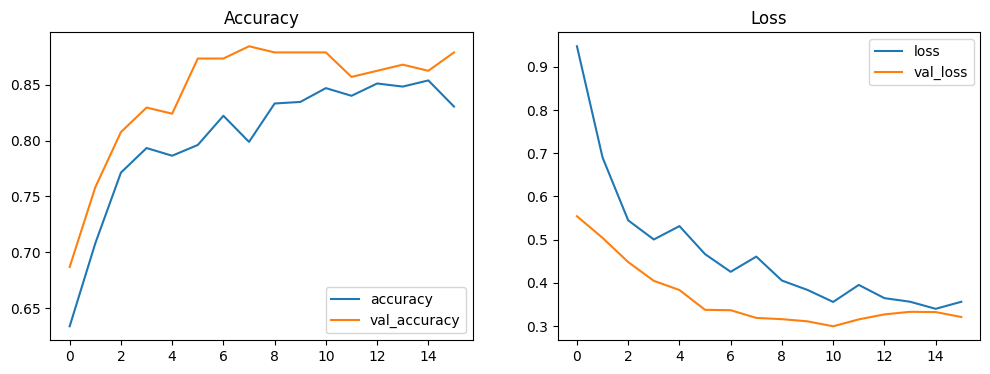

In [18]:
# ==========================================
# STEP 15: Training Graphs
# ==========================================
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1,2, figsize=(12,4))

history_df[['accuracy','val_accuracy']].plot(ax=ax[0])
ax[0].set_title("Accuracy")

history_df[['loss','val_loss']].plot(ax=ax[1])
ax[1].set_title("Loss")

plt.show()

In [19]:
# ==========================================
# STEP 16: Evaluation
# ==========================================
Y_pred = model.predict(X_val)

Y_pred_classes = np.argmax(Y_pred, axis=1)

Y_true = np.argmax(Y_val, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 73s 11s/step


In [20]:
# ==========================================
# Classification Report
# ==========================================
print(classification_report(Y_true, Y_pred_classes, target_names=classes))

                precision    recall  f1-score   support

  healthy iris       0.87      0.85      0.86        80
unhealthy iris       0.88      0.90      0.89       102

      accuracy                           0.88       182
     macro avg       0.88      0.88      0.88       182
  weighted avg       0.88      0.88      0.88       182



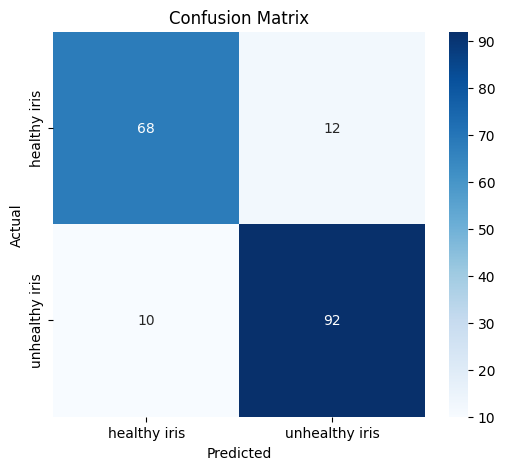

In [21]:
# ==========================================
# STEP 17: Confusion Matrix
# ==========================================
cm = confusion_matrix(Y_true, Y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [22]:
# ==========================================
# STEP 18: Calculate Accuracy %
# ==========================================
accuracy = np.sum(Y_pred_classes == Y_true) / len(Y_true) * 100

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 87.91%


In [23]:
# ==========================================
# STEP 19: Upload Image and Predict
# ==========================================
from google.colab import files

uploaded = files.upload()

Saving 34.jpeg to 34.jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediction: healthy iris (98.87%)


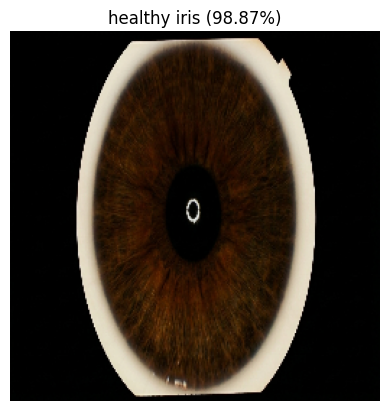

In [24]:

for fname in uploaded.keys():

    img = cv2.imread(fname)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img_array = np.expand_dims(img, axis=0)

    pred = model.predict(img_array)

    pred_class = np.argmax(pred)

    confidence = pred[0][pred_class] * 100

    print(f"Prediction: {classes[pred_class]} ({confidence:.2f}%)")

    plt.imshow(img)

    plt.axis("off")

    plt.title(f"{classes[pred_class]} ({confidence:.2f}%)")

    plt.show()

In [25]:
# ==========================================
# Upload Image and Predict
# ==========================================
from google.colab import files

uploaded = files.upload()

Saving 1 (126).jpg to 1 (126).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
Prediction: unhealthy iris (93.40%)


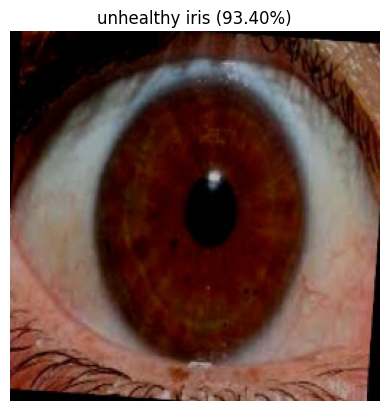

In [26]:
for fname in uploaded.keys():

    img = cv2.imread(fname)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img_array = np.expand_dims(img, axis=0)

    pred = model.predict(img_array)

    pred_class = np.argmax(pred)

    confidence = pred[0][pred_class] * 100

    print(f"Prediction: {classes[pred_class]} ({confidence:.2f}%)")

    plt.imshow(img)

    plt.axis("off")

    plt.title(f"{classes[pred_class]} ({confidence:.2f}%)")

    plt.show()

In [27]:
# ==========================================
# STEP 20: Save Model
# ==========================================
model.save("/content/drive/MyDrive/health_iris_model.keras")